# Shooting method estilo "herramienta interna de Rockstar 2006"

Reconstruccion de como probablemente se generaba la tabla `ShotVar[target][spin]`
de *Rockstar Games Presents Table Tennis*: no en runtime (la Wii nunca podria
iterar en vivo), sino offline, con un script que corre la fisica real una y
otra vez hasta encontrar la velocidad inicial que acierta al target.

Este notebook:
1. Implementa una fisica simplificada estilo RTT (Euler semi-implicito, drag
   lineal, Magnus emergente por spin).
2. Implementa el shooting method (con backtracking, para no divergir).
3. Modela el spin como lo hace RTT real: eje (5 estados) x tabla de
   intensidad x multiplicador de categoria x carga continua -- no un solo
   numero fijo.
4. Agrega `param3`: una correccion angular extra, identica en espiritu a la
   que `AUTOAIM_RTT.md` documenta solo para right-spin -- aca aparece sola,
   sin forzarla, exactamente en los casos que la necesitan.
5. Chequea holgura de red y grafica la convergencia del solver.


## 1. Fisica (estilo RTT: Euler semi-implicito, drag lineal, Magnus simplificado)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
import pandas as pd

%matplotlib inline

G = 9.8                  # gravedad efectiva (g_world * gravityFactor)
DT = 1.0 / 60.0           # dt fijo, igual que RTT (Wii 60 Hz)
DRAG_COEF = 0.06          # decaimiento lineal de velocidad por segundo ("fudge")
MAGNUS_K = 0.08           # constante que escala la curvatura por spin (estilizado)
BALL_RADIUS = 0.02        # 2 cm, igual que ball.bnd en OVERVIEW_RTT.md
NET_X = 1.37              # mitad de una mesa reglamentaria de 2.74 m
NET_HEIGHT = 0.1525       # 15.25 cm, altura reglamentaria de la red


## 2. Modelo de spin -- fiel a RTT, no un enum con magnitud fija

RTT no usa "5 valores de spin" a secas. Usa:

$$
\omega_{\text{initial}} = \text{SpinLines}[\text{eje}][\text{intensidad}] \cdot \text{SpinMult}[\text{categoria}] \cdot \text{spin\_charge}
$$

- **eje**: 5 estados (`none`, `top`, `back`, `left`, `right`) -- solo la *direccion* del vector de rotacion.
- **SpinLines**: tabla 3x3 (3 ejes x 3 intensidades) cargada de `ballspin.xml` en RTT real.
- **SpinMult[categoria]**: escala segun que tan fuerte fue el swing (normal/hard/really_hard).
- **spin_charge**: valor continuo (cuanto "cargo" el jugador el golpe).


In [4]:
# --- Eje de rotacion (spinType, 5 estados -- AUTOAIM_RTT.md Tabla Idx 0-4) ---
SPIN_AXIS = {
    "none":  np.array([0.0, 0.0, 0.0]),
    "top":   np.array([0.0, 0.0, -1.0]),
    "back":  np.array([0.0, 0.0,  1.0]),
    "left":  np.array([0.0,  1.0, 0.0]),
    "right": np.array([0.0, -1.0, 0.0]),
}

# --- SpinMult[categoria] / PaceMult[categoria] -- AUTOAIM_RTT.md 5.1 ---
CATEGORY_SPIN_MULT = {"normal": 1.0, "hard": 1.35, "really_hard": 1.7}
CATEGORY_PACE_MULT = {"normal": 1.0, "hard": 1.15, "really_hard": 1.3}

# --- SpinLines[spinType][intensidad] -- FISICAS_RTT.md 5.2: tabla 3x3 ---
SPIN_LINES_BASE_MAGNITUDE = {0: 6.0, 1: 12.0, 2: 18.0}  # leve, media, cargada al maximo


def compute_omega(spin_type, category="normal", intensity=2, spin_charge=1.0):
    """omega_initial = SpinLines[eje][intensidad] * SpinMult[categoria] * spin_charge"""
    axis = SPIN_AXIS[spin_type]
    base_mag = SPIN_LINES_BASE_MAGNITUDE[intensity]
    mag = base_mag * CATEGORY_SPIN_MULT[category] * spin_charge
    return axis * mag


## 3. Integrador de fisica -- Euler semi-implicito + drag + Magnus emergente

In [5]:
def simulate(v0, spin_type, p0=(0.2, 0.30, 0.0), target_y=0.0, max_time=2.0,
             category="normal", spin_charge=1.0):
    """Simula el vuelo completo. Devuelve el punto de aterrizaje interpolado y el tiempo de vuelo."""
    p = np.array(p0, dtype=float)
    v = np.array(v0, dtype=float)
    omega = compute_omega(spin_type, category=category, spin_charge=spin_charge)
    t = 0.0
    prev_p = p.copy()

    while t < max_time:
        a_gravity = np.array([0.0, -G, 0.0])
        a_magnus = MAGNUS_K * np.cross(omega, v)     # curvatura emergente (no una fuerza Magnus explicita)
        a = a_gravity + a_magnus

        v = v + a * DT                                # Euler semi-implicito
        v = v * (1.0 - DRAG_COEF * DT)                 # drag lineal "fudge"
        prev_p = p.copy()
        p = p + v * DT
        t += DT

        if p[1] <= target_y and t > 0.05:
            frac = (prev_p[1] - target_y) / (prev_p[1] - p[1])
            land = prev_p + frac * (p - prev_p)
            t_land = t - DT + frac * DT
            return land[0], land[2], t_land

    return p[0], p[2], t


def simulate_trajectory(v0, spin_type, p0=(0.2, 0.30, 0.0), target_y=0.0, max_time=2.0,
                         category="normal", spin_charge=1.0):
    """Igual que simulate(), pero devuelve el camino completo (para graficar)."""
    p = np.array(p0, dtype=float)
    v = np.array(v0, dtype=float)
    omega = compute_omega(spin_type, category=category, spin_charge=spin_charge)
    path = [p.copy()]
    t = 0.0
    while t < max_time:
        a = np.array([0.0, -G, 0.0]) + MAGNUS_K * np.cross(omega, v)
        v = v + a * DT
        v = v * (1.0 - DRAG_COEF * DT)
        p = p + v * DT
        path.append(p.copy())
        t += DT
        if p[1] <= target_y and t > 0.05:
            break
    return np.array(path)


def net_clearance(v0, spin_type, p0=(0.2, 0.30, 0.0), category="normal", spin_charge=1.0):
    """Altura de la trayectoria al cruzar x = NET_X. margen < 0 = pega la red."""
    path = simulate_trajectory(v0, spin_type, p0=p0, category=category, spin_charge=spin_charge)
    xs, ys = path[:, 0], path[:, 1]
    idx = np.searchsorted(xs, NET_X)
    if idx <= 0 or idx >= len(xs):
        return None, None
    x0, x1 = xs[idx - 1], xs[idx]
    y0, y1 = ys[idx - 1], ys[idx]
    frac = 0.0 if x1 == x0 else (NET_X - x0) / (x1 - x0)
    y_at_net = y0 + frac * (y1 - y0)
    margin = y_at_net - (NET_HEIGHT + BALL_RADIUS)
    return y_at_net, margin


## 4. Estimacion inicial cerrada (balistica ideal, sin drag ni spin)

$$
v_{y0} = \sqrt{2 g\, h_{\text{apex}}}, \qquad
t_{\text{total}} = \frac{v_{y0} + \sqrt{v_{y0}^2 - 2g(y_1-y_0)}}{g}, \qquad
v_x = \frac{x_1-x_0}{t_{\text{total}}},\ \ v_z = \frac{z_1-z_0}{t_{\text{total}}}
$$

`extra_angle` es `param3`: una rotacion extra sobre la direccion horizontal,
identica en espiritu al cuarto float que `AUTOAIM_RTT.md` documenta solo
para right-spin. En 0.0 es exactamente la formula normal.


In [6]:
def initial_guess(p0, target_xz, apex_height=0.6, extra_angle=0.0):
    x0, y0, z0 = p0
    tx, tz = target_xz
    vy0 = np.sqrt(2 * G * apex_height)
    disc = max(vy0 ** 2 - 2 * G * (0.0 - y0), 0.0)
    t_total = (vy0 + np.sqrt(disc)) / G
    vx = (tx - x0) / t_total
    vz = (tz - z0) / t_total

    if extra_angle != 0.0:
        c, s = np.cos(extra_angle), np.sin(extra_angle)
        vx, vz = vx * c - vz * s, vx * s + vz * c

    return np.array([vx, vy0, vz]), t_total


## 5. Shooting method -- con backtracking

Sin amortiguar el paso, el metodo diverge en configuraciones de spin donde la
curvatura retroalimenta la propia velocidad horizontal. El backtracking
(reducir el paso a la mitad si el error empeora) es lo que evita eso -- ningun
solver serio usa correccion proporcional pura sin control de paso.


In [7]:
def shooting_method(target_xz, spin_type, p0=(0.2, 0.30, 0.0),
                     iterations=10, gain=0.9, verbose=False,
                     category="normal", spin_charge=1.0, apex_height=0.6,
                     extra_angle=0.0):
    sim = lambda v: simulate(v, spin_type, p0=p0, category=category, spin_charge=spin_charge)

    v_guess, t_est = initial_guess(p0, target_xz, apex_height=apex_height, extra_angle=extra_angle)
    v_guess[0] *= CATEGORY_PACE_MULT[category]   # PaceMult[categoria], AUTOAIM_RTT.md 5.1
    v_guess[2] *= CATEGORY_PACE_MULT[category]
    x_land, z_land, t_land = sim(v_guess)
    error = np.array([target_xz[0] - x_land, target_xz[1] - z_land])
    error_norm = np.linalg.norm(error)
    history = [(0, v_guess.copy(), (x_land, z_land), error_norm)]

    if verbose:
        print(f"  iter 0: v=({v_guess[0]:+.3f},{v_guess[1]:+.3f},{v_guess[2]:+.3f})  "
              f"cae en ({x_land:+.3f},{z_land:+.3f})  error={error_norm:.4f} m")

    for i in range(1, iterations):
        if error_norm < 0.005:   # 5 mm de tolerancia -- convergio
            break

        delta = gain * error / t_land
        step_scale = 1.0
        v_try = v_guess.copy()
        err_try = error_norm

        for _ in range(6):   # backtracking: si empeora, reduce el paso a la mitad
            v_try = v_guess.copy()
            v_try[0] += step_scale * delta[0]
            v_try[2] += step_scale * delta[1]
            xl, zl, tl = sim(v_try)
            err_try = np.linalg.norm([target_xz[0] - xl, target_xz[1] - zl])
            if err_try < error_norm:
                break
            step_scale *= 0.5

        v_guess = v_try
        x_land, z_land, t_land = xl, zl, tl
        error = np.array([target_xz[0] - x_land, target_xz[1] - z_land])
        error_norm = err_try
        history.append((i, v_guess.copy(), (x_land, z_land), error_norm))

        if verbose:
            print(f"  iter {i}: v=({v_guess[0]:+.3f},{v_guess[1]:+.3f},{v_guess[2]:+.3f})  "
                  f"cae en ({x_land:+.3f},{z_land:+.3f})  error={error_norm:.4f} m  "
                  f"(paso x{step_scale:.3f})")

    return v_guess, history


## 6. Busqueda adaptativa de apex + param3

1. Primero intenta **sin** `param3` (el caso normal: none/top/back/left en RTT real).
2. Solo si ninguna altura de arco converge, busca un `param3` (angulo extra)
   -- el caso especial que en RTT real solo se documenta para right-spin.


In [8]:
def shooting_method_adaptive(target_xz, spin_type, p0=(0.2, 0.30, 0.0), verbose=False,
                              category="normal", spin_charge=1.0):
    best_v, best_hist, best_apex = None, None, None
    for apex in [0.6, 1.0, 1.5, 2.2, 3.0]:
        v_final, hist = shooting_method(target_xz, spin_type, p0=p0, apex_height=apex,
                                         category=category, spin_charge=spin_charge)
        if best_hist is None or hist[-1][3] < best_hist[-1][3]:
            best_v, best_hist, best_apex = v_final, hist, apex
        if hist[-1][3] < 0.02:
            return best_v, best_hist, best_apex, 0.0   # param3 = 0, no hizo falta

    # ninguna altura de arco alcanzo -- buscar param3 (angulo extra)
    for angle_deg in [10, 20, 30, 45, -10, -20, -30, -45]:
        angle = np.radians(angle_deg)
        for apex in [0.6, 1.0, 1.5, 2.2, 3.0]:
            v_final, hist = shooting_method(target_xz, spin_type, p0=p0, apex_height=apex,
                                             category=category, spin_charge=spin_charge,
                                             extra_angle=angle)
            if hist[-1][3] < best_hist[-1][3]:
                best_v, best_hist, best_apex = v_final, hist, apex
            if hist[-1][3] < 0.02:
                if verbose:
                    print(f"    (convergio con param3={angle_deg} grados, apex={apex} m)")
                return v_final, hist, apex, angle

    return best_v, best_hist, best_apex, 0.0


## 7. Demo 1 -- convergencia visible para un solo (target, spin)

In [23]:
target_demo = (2.4, 0.55)   # (x, z) -- mesa larga ~2.74 m, ancha ~1.52 m
v_final, demo1_hist = shooting_method(target_demo, "right", verbose=True, iterations = 128)

print(f"\n-> VELOCIDAD INICIAL FINAL: {v_final}")
y_net, margin = net_clearance(v_final, "top")
print(f"-> altura al pasar la red (x={NET_X} m): {y_net:.3f} m "
      f"(margen = {margin*100:+.1f} cm {'OK' if margin >= 0 else 'PEGA RED'})")
print("-> (esto es exactamente el vector que RTT habria guardado en ShotVar)")


  iter 0: v=(+2.826,+3.429,+0.706)  cae en (+1.641,+1.486)  error=1.2055 m
  iter 1: v=(+3.725,+3.429,-0.403)  cae en (+2.600,+1.154)  error=0.6363 m  (paso x1.000)
  iter 2: v=(+3.489,+3.429,-1.118)  cae en (+2.725,+0.634)  error=0.3358 m  (paso x1.000)
  iter 3: v=(+3.104,+3.429,-1.217)  cae en (+2.530,+0.429)  error=0.1773 m  (paso x1.000)
  iter 4: v=(+2.950,+3.429,-1.074)  cae en (+2.383,+0.458)  error=0.0936 m  (paso x1.000)
  iter 5: v=(+2.970,+3.429,-0.965)  cae en (+2.354,+0.531)  error=0.0494 m  (paso x1.000)
  iter 6: v=(+3.024,+3.429,-0.943)  cae en (+2.379,+0.565)  error=0.0261 m  (paso x1.000)
  iter 7: v=(+3.049,+3.429,-0.961)  cae en (+2.401,+0.564)  error=0.0138 m  (paso x1.000)
  iter 8: v=(+3.048,+3.429,-0.977)  cae en (+2.406,+0.554)  error=0.0073 m  (paso x1.000)
  iter 9: v=(+3.041,+3.429,-0.981)  cae en (+2.403,+0.548)  error=0.0038 m  (paso x1.000)

-> VELOCIDAD INICIAL FINAL: [ 3.04092784  3.42928564 -0.98116508]
-> altura al pasar la red (x=1.37 m): 0.577 m (m

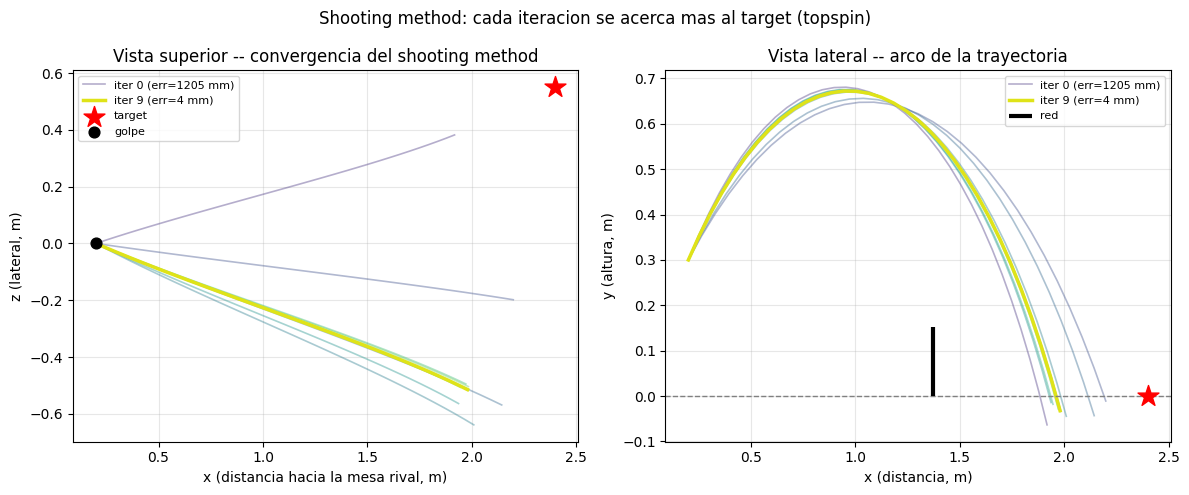

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_iters = len(demo1_hist)
colors = viridis(np.linspace(0.15, 0.95, n_iters))

for (i, v_guess, landing, err), color in zip(demo1_hist, colors):
    path = simulate_trajectory(v_guess, "top")
    alpha = 0.4 if i < n_iters - 1 else 1.0
    lw = 1.2 if i < n_iters - 1 else 2.5
    label = f"iter {i} (err={err*1000:.0f} mm)" if i in (0, n_iters - 1) else None

    axes[0].plot(path[:, 0], path[:, 2], color=color, alpha=alpha, lw=lw, label=label)
    axes[1].plot(path[:, 0], path[:, 1], color=color, alpha=alpha, lw=lw, label=label)

axes[0].scatter(*target_demo, marker="*", s=250, color="red", zorder=5, label="target")
axes[0].scatter(0.2, 0.0, marker="o", s=60, color="black", zorder=5, label="golpe")
axes[0].set_xlabel("x (distancia hacia la mesa rival, m)")
axes[0].set_ylabel("z (lateral, m)")
axes[0].set_title("Vista superior -- convergencia del shooting method")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="gray", lw=1, ls="--")
axes[1].plot([NET_X, NET_X], [0, NET_HEIGHT], color="black", lw=3, solid_capstyle="butt",
             label="red", zorder=4)
axes[1].scatter(target_demo[0], 0.0, marker="*", s=250, color="red", zorder=5)
axes[1].set_xlabel("x (distancia, m)")
axes[1].set_ylabel("y (altura, m)")
axes[1].set_title("Vista lateral -- arco de la trayectoria")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.suptitle("Shooting method: cada iteracion se acerca mas al target (topspin)")
fig.tight_layout()
plt.show()


## 8. Demo 2 -- el barrido completo

6 targets x 5 spins x 3 categorias = **90 combinaciones** -- el mismo orden
de magnitud que los "~90 preseteos basicos" que documenta `AUTOAIM_RTT.md` §7
para RTT real.


In [11]:
from tqdm.auto import tqdm
import itertools

targets = {
    "far-left":    (2.5, -0.5),
    "far-center":  (2.5,  0.0),
    "far-right":   (2.5,  0.5),
    "near-left":   (1.6, -0.5),
    "near-center": (1.6,  0.0),
    "near-right":  (1.6,  0.5),
}
spins = ["none", "top", "back", "left", "right"]
categories = ["normal", "hard", "really_hard"]

combos = list(itertools.product(targets.items(), spins, categories))

rows = []
for (tname, txz), spin, cat in tqdm(combos, desc="Barriendo target x spin x categoria"):
    v, hist, apex_used, param3 = shooting_method_adaptive(txz, spin, category=cat)
    err_mm = hist[-1][3] * 1000
    _, margin = net_clearance(v, spin, category=cat)
    margin_cm = margin * 100 if margin is not None else np.nan
    rows.append({
        "target": tname, "spin": spin, "categoria": cat,
        "vx": v[0], "vy0": v[1], "vz": v[2],
        "apex_m": apex_used, "param3_deg": np.degrees(param3),
        "error_mm": err_mm, "margen_red_cm": margin_cm,
        "pega_red": margin is not None and margin < 0,
    })

df = pd.DataFrame(rows)
df

Barriendo target x spin x categoria:   0%|          | 0/90 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
n_total = len(df)
net_fails = df["pega_red"].sum()
param3_used = (df["param3_deg"] != 0.0).sum()

print(f"Total de combinaciones: {n_total}")
print(f"Pegan la red: {net_fails}")
print(f"Necesitaron param3: {param3_used} de {n_total} "
      f"-- el mismo tipo de correccion asimetrica que RTT solo documenta para right-spin")

df[df["param3_deg"] != 0]


Total de combinaciones: 90
Pegan la red: 0
Necesitaron param3: 12 de 90 -- el mismo tipo de correccion asimetrica que RTT solo documenta para right-spin


,target,spin,categoria,vx,vy0,vz,apex_m,param3_deg,error_mm,margen_red_cm,pega_red
10,far-left,left,hard,2.964614,3.429286,1.783389,0.6,30.0,18.569323,69.008236,False
13,far-left,right,hard,1.956654,3.429286,-2.853230,0.6,-30.0,18.569323,66.494275,False
25,far-center,left,hard,2.460634,3.429286,2.318310,0.6,30.0,18.145503,68.182214,False
28,far-center,right,hard,2.460634,3.429286,-2.318310,0.6,-30.0,18.145503,68.182214,False
40,far-right,left,hard,1.956654,3.429286,2.853230,0.6,30.0,18.569323,66.494275,False
43,far-right,right,hard,2.964614,3.429286,-1.783389,0.6,-30.0,18.569323,69.008236,False
55,near-left,left,hard,2.001758,3.429286,0.876225,0.6,30.0,11.728361,41.291677,False
58,near-left,right,hard,0.993797,3.429286,-1.946066,0.6,-30.0,11.728361,23.558331,False
70,near-center,left,hard,1.504320,3.429286,1.421681,0.6,20.0,19.387123,32.541442,False
73,near-center,right,hard,1.504320,3.429286,-1.421681,0.6,-20.0,19.387123,32.541442,False


## 9. Plot -- como cada iteracion del shooting method se acerca al target

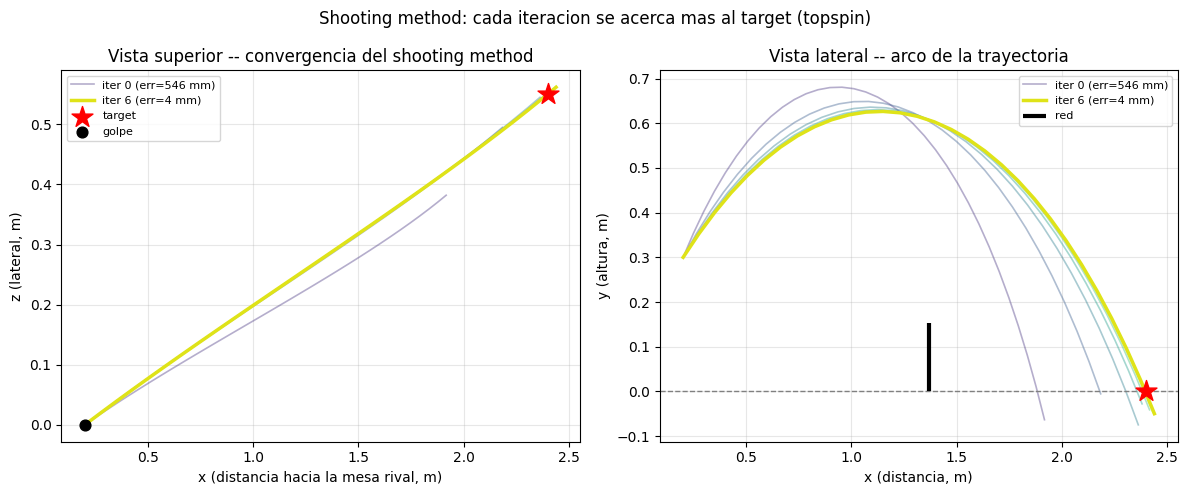

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_iters = len(demo1_hist)
colors = viridis(np.linspace(0.15, 0.95, n_iters))

for (i, v_guess, landing, err), color in zip(demo1_hist, colors):
    path = simulate_trajectory(v_guess, "top")
    alpha = 0.4 if i < n_iters - 1 else 1.0
    lw = 1.2 if i < n_iters - 1 else 2.5
    label = f"iter {i} (err={err*1000:.0f} mm)" if i in (0, n_iters - 1) else None

    axes[0].plot(path[:, 0], path[:, 2], color=color, alpha=alpha, lw=lw, label=label)
    axes[1].plot(path[:, 0], path[:, 1], color=color, alpha=alpha, lw=lw, label=label)

axes[0].scatter(*target_demo, marker="*", s=250, color="red", zorder=5, label="target")
axes[0].scatter(0.2, 0.0, marker="o", s=60, color="black", zorder=5, label="golpe")
axes[0].set_xlabel("x (distancia hacia la mesa rival, m)")
axes[0].set_ylabel("z (lateral, m)")
axes[0].set_title("Vista superior -- convergencia del shooting method")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="gray", lw=1, ls="--")
axes[1].plot([NET_X, NET_X], [0, NET_HEIGHT], color="black", lw=3, solid_capstyle="butt",
             label="red", zorder=4)
axes[1].scatter(target_demo[0], 0.0, marker="*", s=250, color="red", zorder=5)
axes[1].set_xlabel("x (distancia, m)")
axes[1].set_ylabel("y (altura, m)")
axes[1].set_title("Vista lateral -- arco de la trayectoria")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.suptitle("Shooting method: cada iteracion se acerca mas al target (topspin)")
fig.tight_layout()
plt.show()
